<div style="background-color:#0077BE; padding:15px; border-radius:10px;">
    <h1 style="color:white; margin:0;">Water Quality Analysis</h1>
</div>

<br>

<h3>Tujuan</h3>
<p>
Menganalisis parameter kualitas air dan memprediksi apakah air <b>layak diminum (potable)</b> atau <b>tidak layak diminum (not potable)</b> berdasarkan karakteristik fisikokimia air.
</p>

<h3>Dataset</h3>
<p>
Dataset yang digunakan adalah <b>Water Potability Dataset</b> dari Kaggle yang berisi berbagai parameter kualitas air seperti pH, hardness, solids, chloramines, sulfate, dan lainnya.
</p>

<p>
<a href="https://www.kaggle.com/datasets/adityakadiwal/water-potability" target="_blank">
https://www.kaggle.com/datasets/adityakadiwal/water-potability
</a>
</p>

In [1]:
# Impor library
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)

# Imbalanced-learn untuk handling class imbalance
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    print("Warning: imblearn tidak tersedia. Install dengan: pip install imbalanced-learn")

import xgboost as xgb
import lightgbm as lgb
import shap
import kagglehub

print("Library berhasil diimpor.")

Library berhasil diimpor.


In [2]:
# Konfigurasi tampilan
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

# Konstanta global
RANDOM_STATE = 42
WARNA_KELAS = {"Tidak Layak": "#e07b54", "Layak Minum": "#5b8db8"}

print("Lingkungan berhasil dikonfigurasi.")

Lingkungan berhasil dikonfigurasi.


<div style="background-color:#0077BE; padding:15px; border-radius:10px;">
    <h1 style="color:white; margin:0;">Dataset</h1>
</div>

In [3]:
# Path ke dataset lokal
path = "D:/A11.2025.16609/SEMESTER 2/PEMBELAJARAN MESIN - A11.4405/project/"
df = pd.read_csv(os.path.join(path, "water_quality_data.csv"))

print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


In [4]:
# Menampilkan 5 baris pertama dataset
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.8905,20791.3190,7.3002,368.5164,564.3087,10.3798,86.9910,2.9631,0
1,3.7161,129.4229,18630.0579,6.6352,NaN,592.8854,15.1800,56.3291,4.5007,0
2,8.0991,224.2363,19909.5417,9.2759,NaN,418.6062,16.8686,66.4201,3.0559,0
3,8.3168,214.3734,22018.4174,8.0593,356.8861,363.2665,18.4365,100.3417,4.6288,0
4,9.0922,181.1015,17978.9863,6.5466,310.1357,398.4108,11.5583,31.9980,4.0751,0


In [5]:
# Menampilkan ringkasan dataset secara terstruktur
def dataset_summary(dataframe):
    """Menampilkan ringkasan terstruktur dataset: dimensi, tipe data, nilai kosong, dan duplikat."""
    print("=" * 75)
    print("RINGKASAN DATASET")
    print("=" * 75)
    print(f"Jumlah Baris        : {dataframe.shape[0]}")
    print(f"Jumlah Kolom        : {dataframe.shape[1]}")
    print(f"Baris Duplikat      : {dataframe.duplicated().sum()}")
    print(f"Total Nilai Kosong  : {dataframe.isnull().sum().sum()}")
    print()
    print("-" * 75)
    print("INFORMASI KOLOM")
    print("-" * 75)
    info_df = pd.DataFrame({
        "Tipe Data": dataframe.dtypes,
        "Jumlah Kosong": dataframe.isnull().sum(),
        "Persen Kosong (%)": (dataframe.isnull().sum() / len(dataframe) * 100).round(2),
        "Nilai Unik": dataframe.nunique()
    })
    print(info_df.to_string())
    print("=" * 75)

dataset_summary(df)

RINGKASAN DATASET
Jumlah Baris        : 3276
Jumlah Kolom        : 10
Baris Duplikat      : 0
Total Nilai Kosong  : 1434

---------------------------------------------------------------------------
INFORMASI KOLOM
---------------------------------------------------------------------------
                Tipe Data  Jumlah Kosong  Persen Kosong (%)  Nilai Unik
ph                float64            491            14.9900        2785
Hardness          float64              0             0.0000        3276
Solids            float64              0             0.0000        3276
Chloramines       float64              0             0.0000        3276
Sulfate           float64            781            23.8400        2495
Conductivity      float64              0             0.0000        3276
Organic_carbon    float64              0             0.0000        3276
Trihalomethanes   float64            162             4.9500        3114
Turbidity         float64              0             0.0000   

In [6]:
# Menampilkan statistik deskriptif untuk kolom numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0000,7.0808,1.5943,0.0000,6.0931,7.0368,8.0621,14.0000
Hardness,3276.0000,196.3695,32.8798,47.4320,176.8505,196.9676,216.6675,323.1240
Solids,3276.0000,22014.0925,8768.5708,320.9426,15666.6903,20927.8336,27332.7621,61227.1960
Chloramines,3276.0000,7.1223,1.5831,0.3520,6.1274,7.1303,8.1149,13.1270
Sulfate,2495.0000,333.7758,41.4168,129.0000,307.6995,333.0735,359.9502,481.0306
Conductivity,3276.0000,426.2051,80.8241,181.4838,365.7344,421.8850,481.7923,753.3426
Organic_carbon,3276.0000,14.2850,3.3082,2.2000,12.0658,14.2183,16.5577,28.3000
Trihalomethanes,3114.0000,66.3963,16.1750,0.7380,55.8445,66.6225,77.3375,124.0000
Turbidity,3276.0000,3.9668,0.7804,1.4500,3.4397,3.9550,4.5003,6.7390
Potability,3276.0000,0.3901,0.4878,0.0000,0.0000,0.0000,1.0000,1.0000


<div style="background-color:#d40457; padding:15px; border-radius:10px;">
    <h1 style="color:white; margin:0;">Exploratory Data Analysis (EDA)</h1>
</div>

### 1. Distribusi Target Variable (Potability)

Pada bagian ini, kita akan menganalisis distribusi kelas target `Potability`:
- **Kelas 0**: Air tidak layak minum
- **Kelas 1**: Air layak minum

Analisis ini penting untuk memahami apakah dataset seimbang (*balanced*) atau tidak seimbang (*imbalanced*)

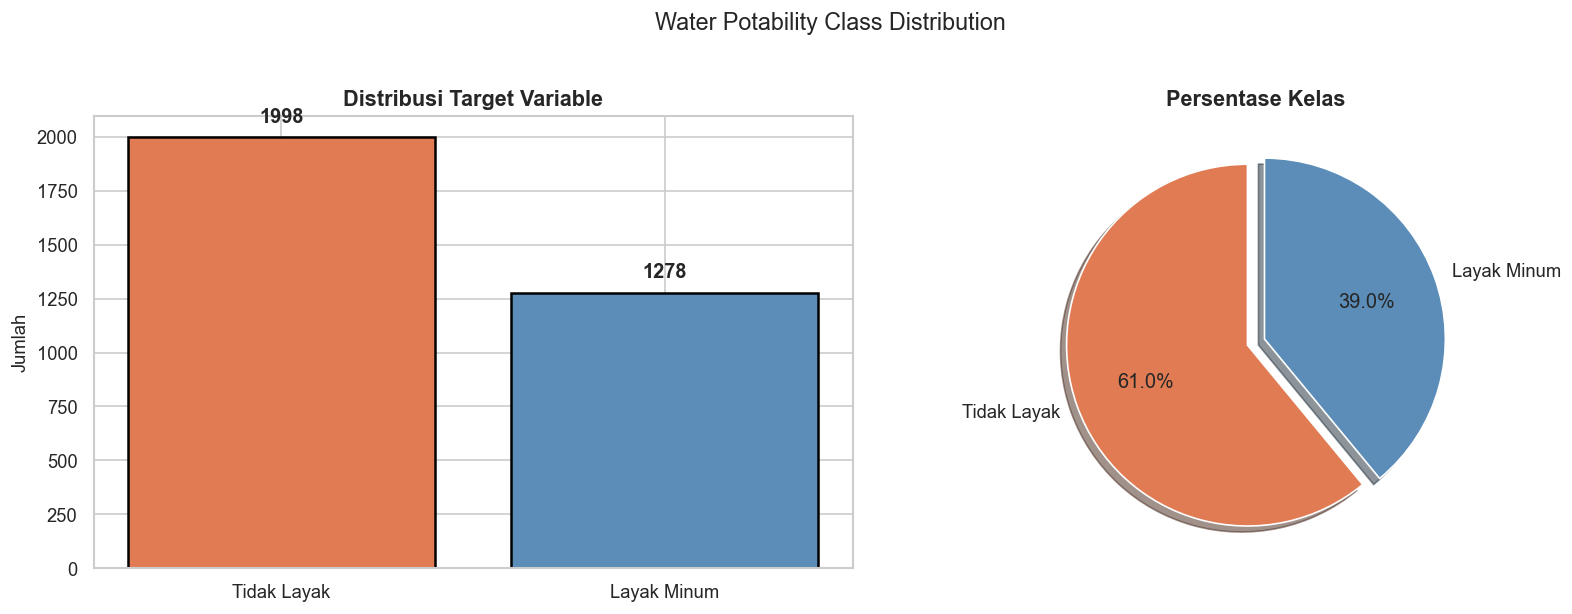

Kelas 0 (Tidak Layak): 1998 sampel (61.0%)
Kelas 1 (Layak Minum): 1278 sampel (39.0%)

Dataset tidak seimbang (imbalanced)


In [7]:
# 1. Distribusi Target Variable (Potability)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
potability_counts = df['Potability'].value_counts()
bars = axes[0].bar(['Tidak Layak', 'Layak Minum'], potability_counts.values, 
                   color=['#e07b54', '#5b8db8'], edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Jumlah', fontsize=11)
axes[0].set_title('Distribusi Target Variable', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=11)

# Add total labels
for bar, count in zip(bars, potability_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
colors = ['#e07b54', '#5b8db8']
axes[1].pie(potability_counts.values, labels=['Tidak Layak', 'Layak Minum'], 
            autopct='%1.1f%%', colors=colors, startangle=90, 
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Persentase Kelas', fontsize=13, fontweight='bold')

plt.suptitle('Water Potability Class Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Total data
total = len(df)

print(f"Kelas 0 (Tidak Layak): {potability_counts[0]} sampel ({potability_counts[0]/total*100:.1f}%)")
print(f"Kelas 1 (Layak Minum): {potability_counts[1]} sampel ({potability_counts[1]/total*100:.1f}%)")
print(f"\nDataset tidak seimbang (imbalanced)" if potability_counts[0] != potability_counts[1] else "✓ Dataset seimbang")

### 2. Visualisasi Missing Values

Pada bagian ini, kita akan menganalisis nilai yang hilang (*missing values*) dalam dataset:

**Visualisasi yang digunakan:**
- **Bar Plot**: Menunjukkan persentase missing values pada setiap kolom fitur

Analisis ini penting untuk menentukan strategi penanganan missing values yang akan digunakan pada tahap preprocessing.

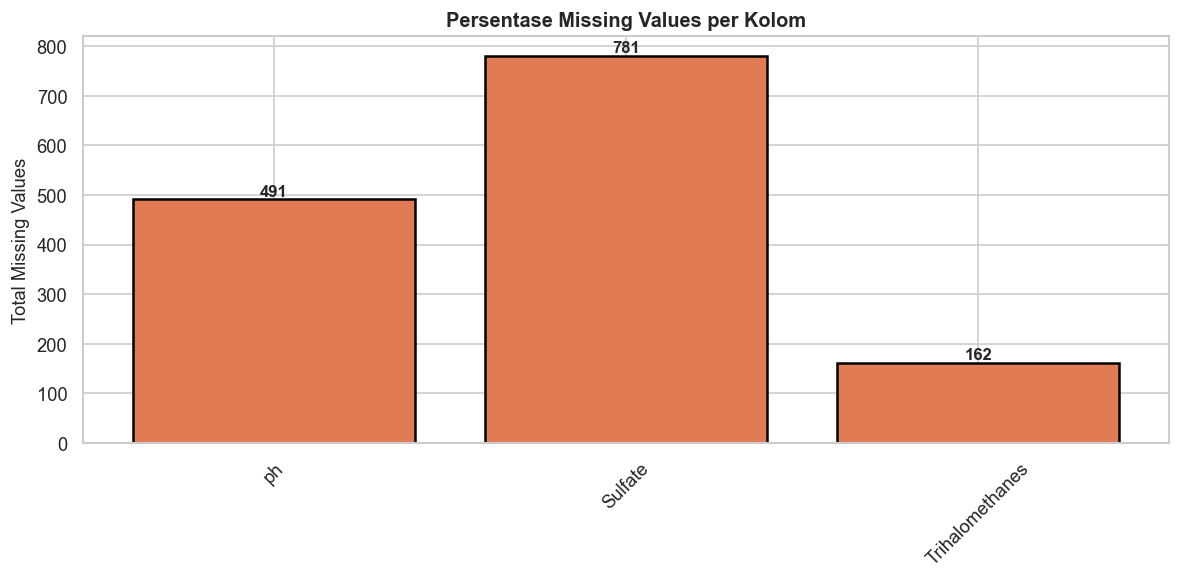


Kolom dengan Missing Values:
  - ph: 491 (14.99%)
  - Sulfate: 781 (23.84%)
  - Trihalomethanes: 162 (4.95%)


In [8]:
# 2. Visualisasi Missing Values

plt.figure(figsize=(10,5))

# Hitung missing values
missing_per_col = df.isnull().sum()
missing_pct = (missing_per_col / len(df) * 100).round(2)

missing_df_plot = pd.DataFrame({
    'Kolom': missing_per_col.index,
    'Missing': missing_per_col.values,
    'Persen': missing_pct
})

missing_df_plot = missing_df_plot[missing_df_plot['Missing'] > 0]

if len(missing_df_plot) > 0:
    bars = plt.bar(missing_df_plot['Kolom'], missing_df_plot['Missing'],
                color='#e07b54', edgecolor='black', linewidth=1.5)

    plt.ylabel('Total Missing Values', fontsize=11)
    plt.title('Persentase Missing Values per Kolom', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)

    # Label jumlah missing di atas bar
    for bar, total in zip(bars, missing_df_plot['Missing']):
        plt.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{total}',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold')
else:
    plt.text(0.5, 0.5, 'Tidak ada missing values',
             ha='center',
             va='center',
             fontsize=14)

plt.tight_layout()
plt.show()

print("\nKolom dengan Missing Values:")
for col in missing_df_plot['Kolom']:
    print(f"  - {col}: {missing_per_col[col]} ({missing_pct[col]}%)")

### 3. Distribusi Numeric Features

Pada bagian ini, kita akan memvisualisasikan distribusi setiap fitur numerik menggunakan histogram dengan KDE (*Kernel Density Estimation*):

**Fitur yang dianalisis:**
- `ph`, `Hardness`, `Solids`, `Chloramines`, `Sulfate`
- `Conductivity`, `Organic_carbon`, `Trihalomethanes`, `Turbidity`

Analisis ini membantu memahami karakteristik data sebelum dilakukan preprocessing.

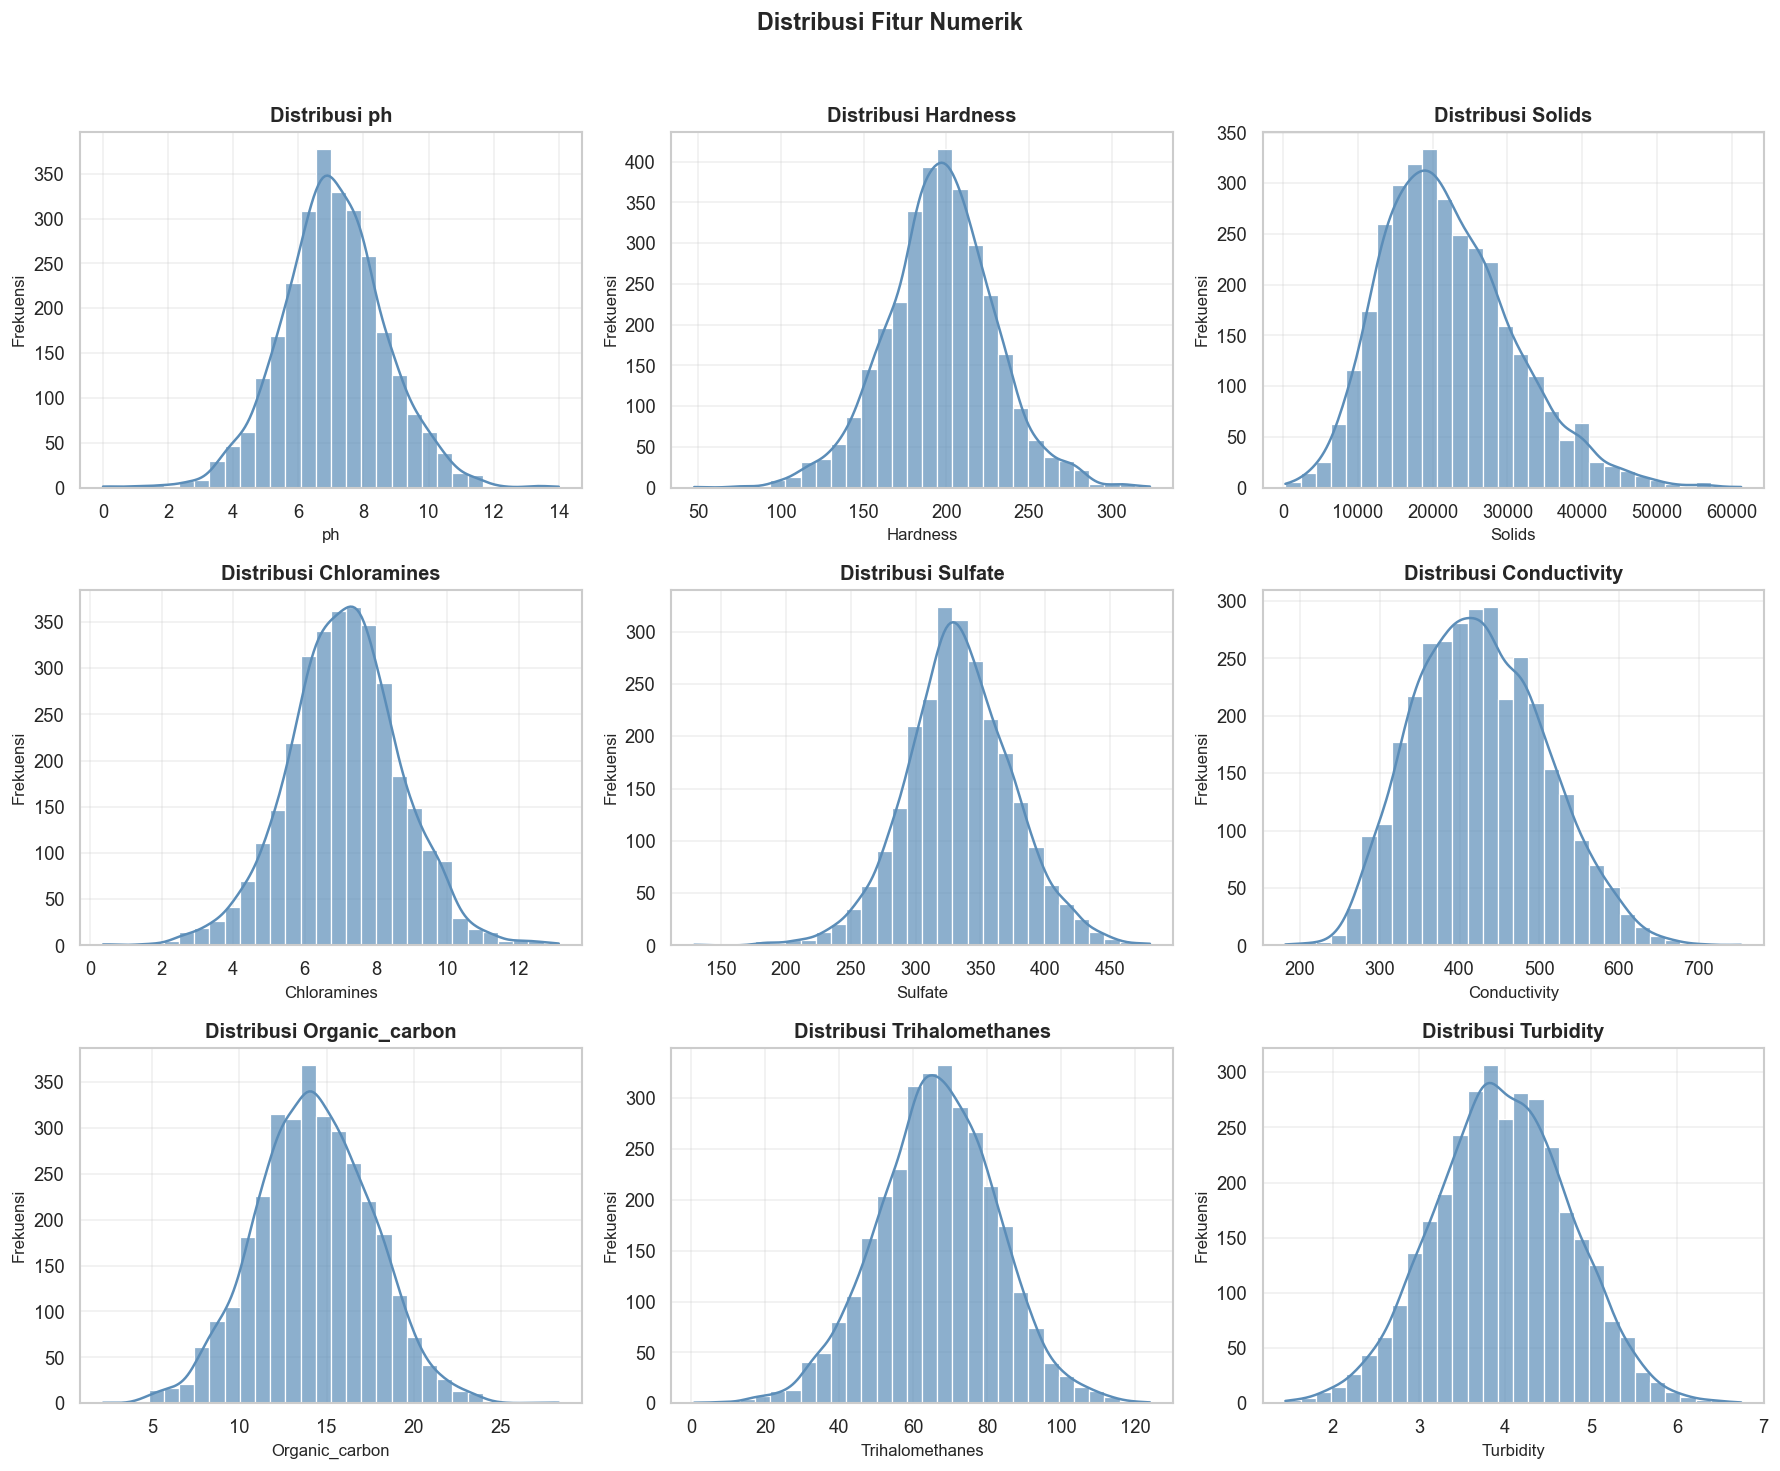

In [9]:
# 3. Distribusi Fitur Numerik
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Histogram + KDE
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i], 
                 color='#5b8db8', alpha=0.7, bins=30)
    axes[i].set_title(f'Distribusi {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Sebagian besar fitur memiliki distribusi mendekati normal, namun beberapa fitur seperti Solids, Conductivity, dan Trihalomethanes menunjukkan distribusi yang condong ke kanan yang mengindikasikan adanya nilai ekstrem pada data.

### 4. Deteksi Outlier dengan Boxplot

Pada bagian ini, kita akan menggunakan boxplot untuk mengidentifikasi keberadaan *outlier* pada setiap fitur numerik:

**Komponen utama boxplot:**
- **Box (Kotak)**: Rentang *Interquartile Range* (IQR) dari Q1 hingga Q3
- **Garis tengah**: Nilai median
- **Whisker**: Batas 1.5 × IQR
- **Titik di luar whisker**: Kandidat outlier

Deteksi outlier penting karena nilai ekstrem dapat mempengaruhi performa model machine learning dan menyebabkan bias dalam pelatihan model.

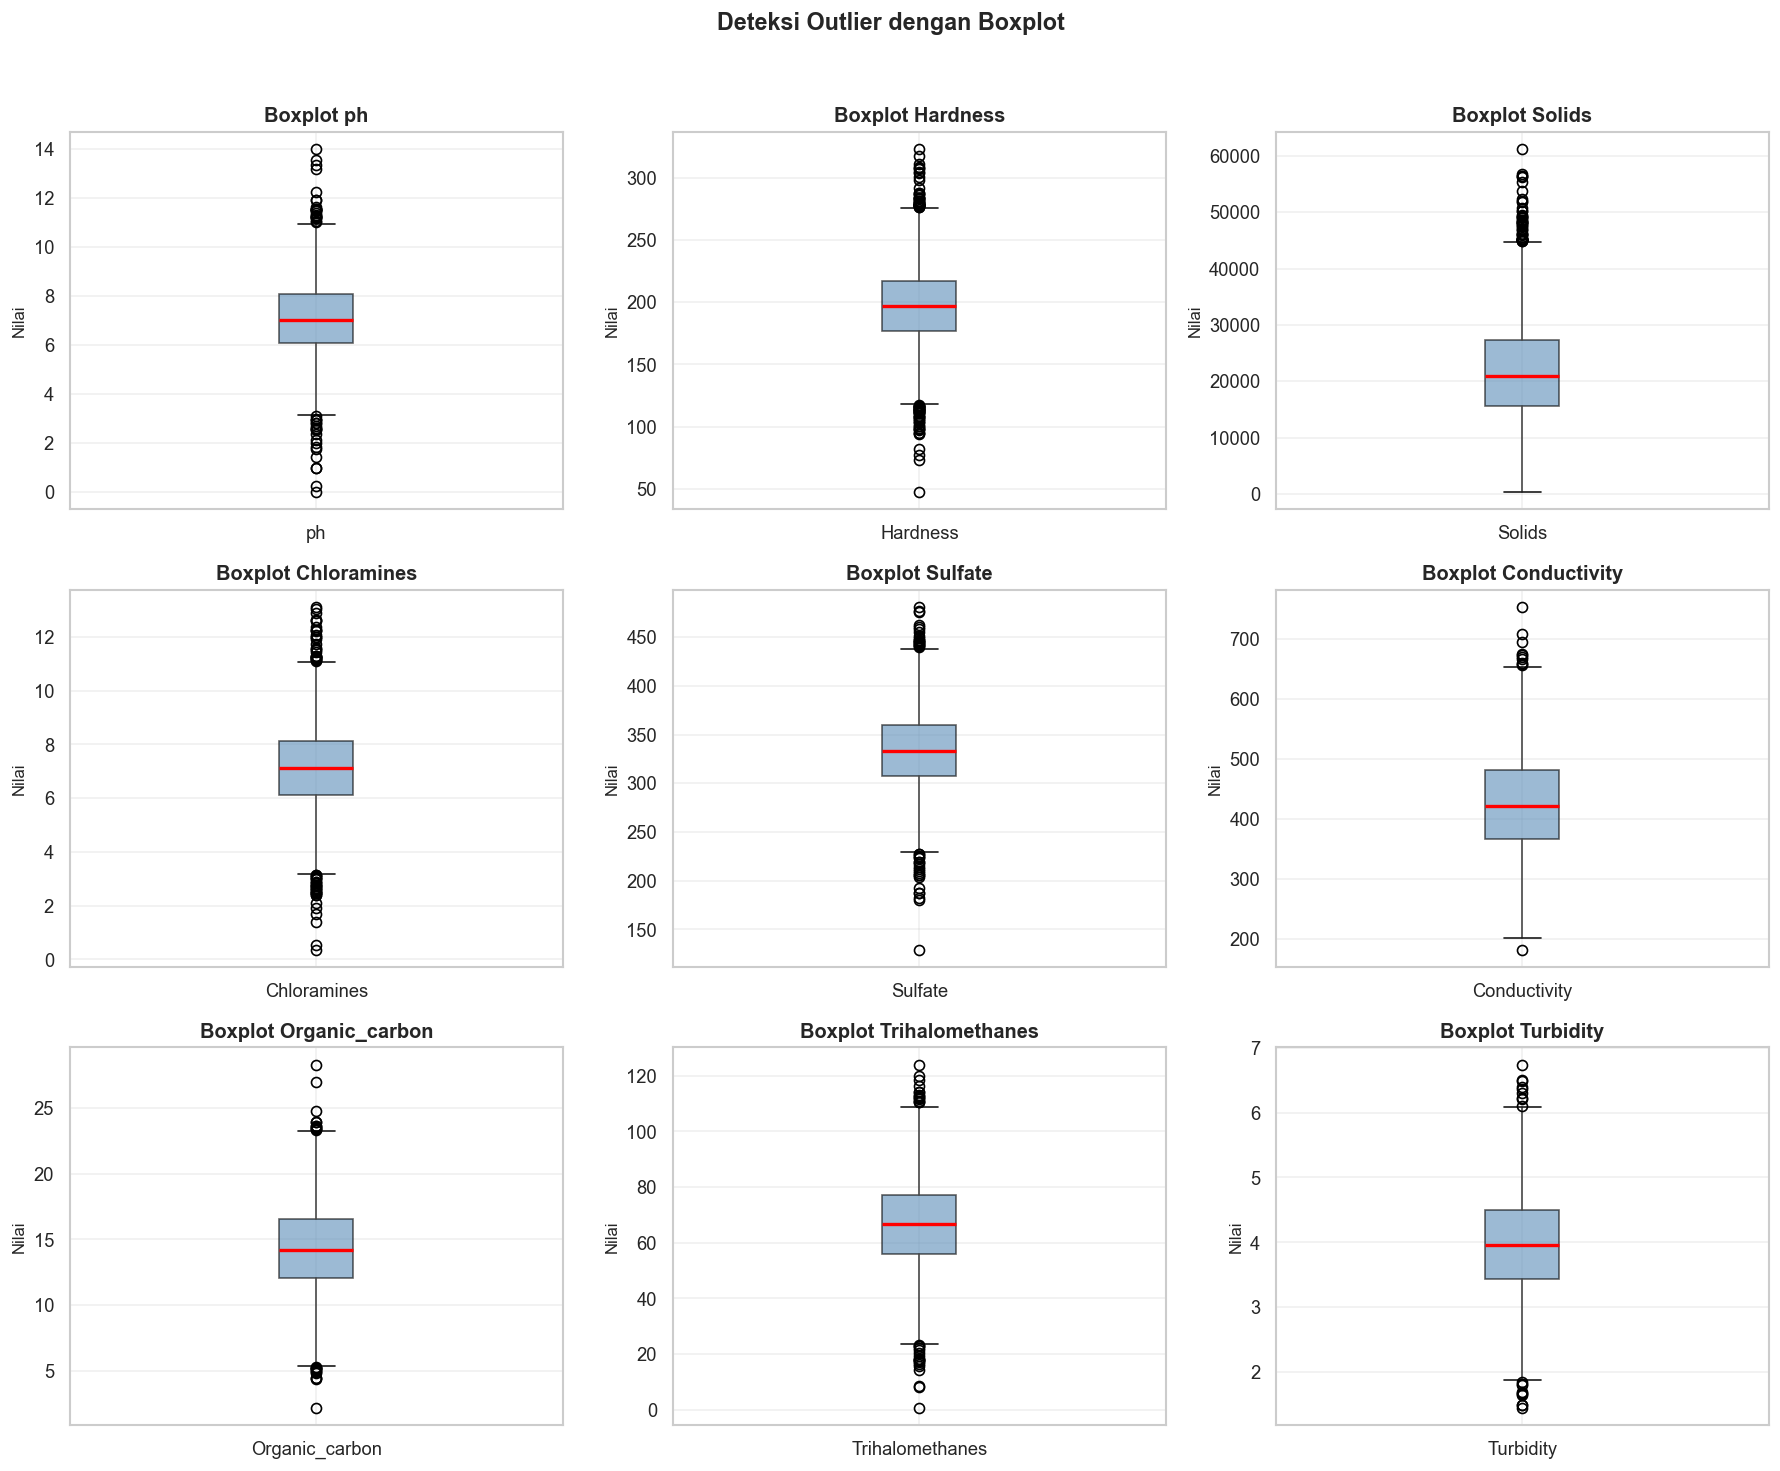


Titik di luar whisker boxplot adalah potential outliers


In [10]:
# 4. Boxplot untuk Deteksi Outlier
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    df.boxplot(column=feature, ax=axes[i], patch_artist=True,
               boxprops=dict(facecolor='#5b8db8', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot {feature}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Deteksi Outlier dengan Boxplot', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nTitik di luar whisker boxplot adalah potential outliers")

### 5. Korelasi Antar Fitur

Pada bagian ini, kita akan menganalisis hubungan linear antar fitur menggunakan *heatmap correlation*:

**Informasi yang didapat dari heatmap:**
- Kekuatan hubungan linear antar fitur (nilai -1 hingga +1)
- Fitur dengan korelasi tinggi yang berpotensi menyebabkan multikolinearitas
- Hubungan antara fitur dengan variabel target untuk identifikasi fitur prediktif

**Catatan:** Segitiga atas matriks korelasi di-*mask* (disembunyikan) untuk mempermudah interpretasi.

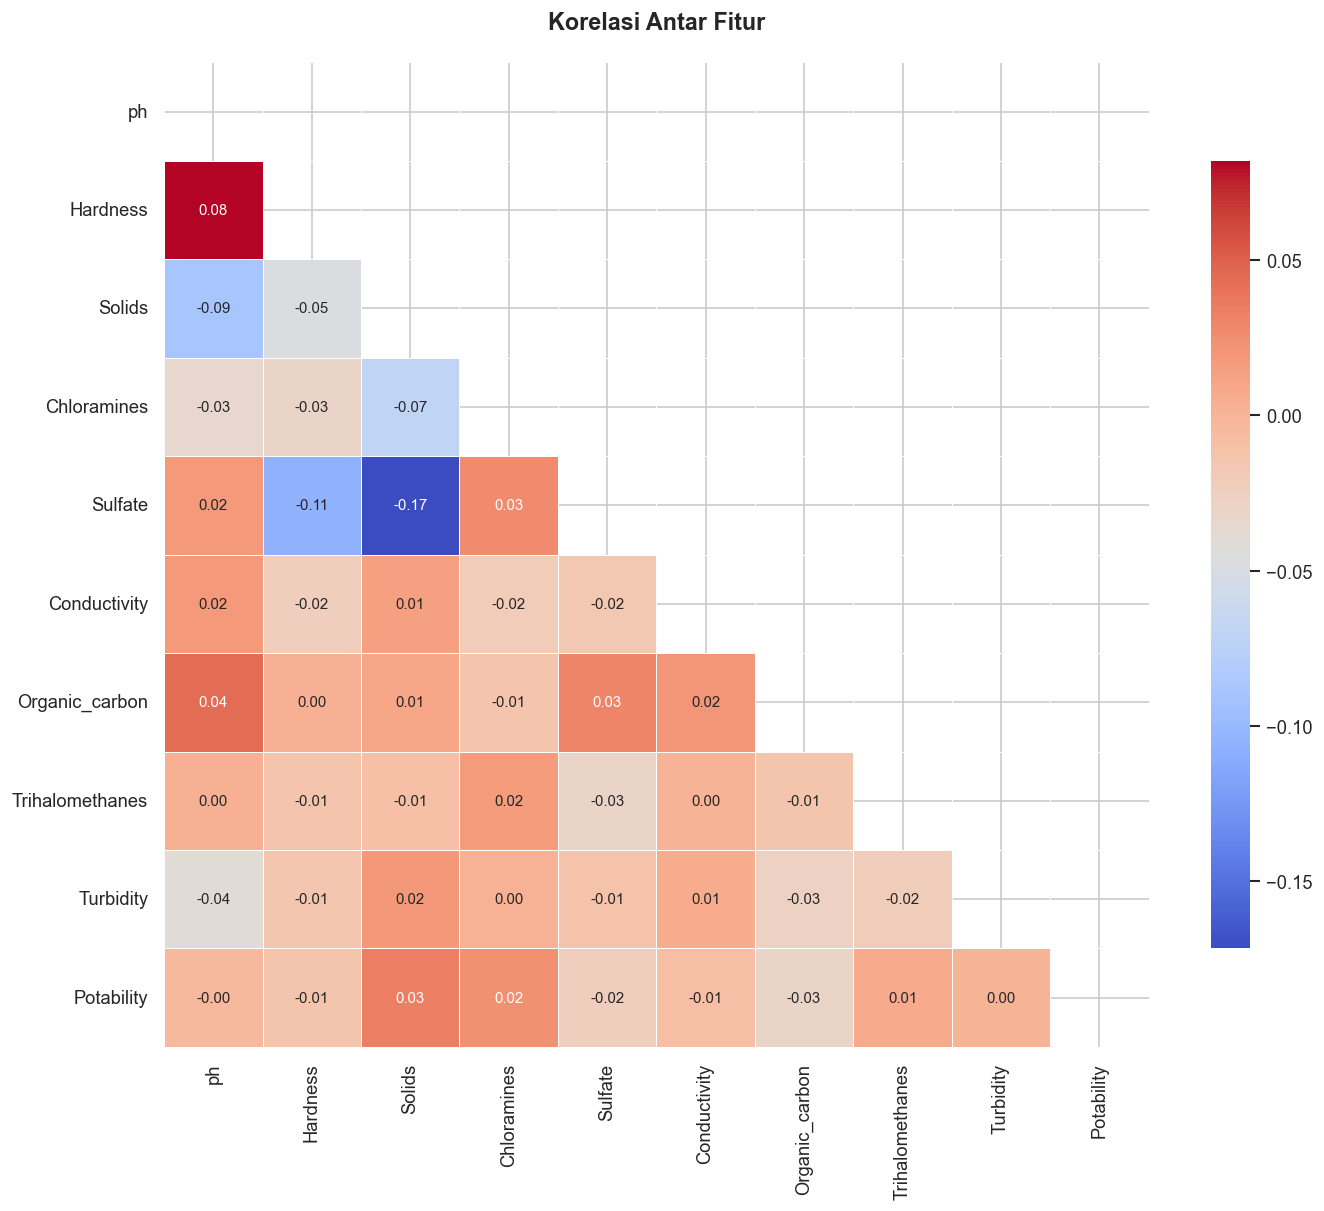


Korelasi Fitur dengan Target (Potability):
  - Solids: 0.034
  - Organic_carbon: 0.030
  - Chloramines: 0.024
  - Sulfate: 0.024
  - Hardness: 0.014
  - Conductivity: 0.008
  - Trihalomethanes: 0.007
  - ph: 0.004
  - Turbidity: 0.002


In [11]:
# 5. Korelasi Antar Fitur
plt.figure(figsize=(12, 10))
corr_matrix = df[features + ['Potability']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
plt.title('Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Korelasi dengan target
print("\nKorelasi Fitur dengan Target (Potability):")
corr_with_target = corr_matrix['Potability'].drop('Potability').abs().sort_values(ascending=False)
for feat, corr in corr_with_target.items():
    print(f"  - {feat}: {corr:.3f}")

Berdasarkan heatmap korelasi antar fitur, sebagian besar variabel memiliki nilai korelasi yang sangat rendah dengan rentang antara -0.17 hingga 0.08. Hal ini menunjukkan bahwa hubungan linear antar fitur dalam dataset relatif lemah. Selain itu, tidak ditemukan multikolinearitas yang signifikan antar variabel. Korelasi antara fitur dengan variabel target (Potability) juga tergolong rendah, sehingga kemungkinan diperlukan kombinasi beberapa fitur untuk membangun model klasifikasi yang efektif.

<div style="background-color:#0077BE; padding:15px; border-radius:10px;">
    <h1 style="color:white; margin:0;">Preprocessing</h1>
</div>

### 1. Memisahkan Features dan Target

Pada bagian ini, dataset dipisahkan menjadi dua bagian:

**Komponen dataset:**
- **X (Features)**: Seluruh kolom fitur selain `Potability`
- **y (Target)**: Kolom `Potability`

**Tujuan pemisahan:**
- Model machine learning membutuhkan input (X) dan output (y) yang terpisah
- Memungkinkan evaluasi performa model pada data test

In [12]:
# 1. Memisahkan Features (X) dan Target (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

Features (X): (3276, 9)
Target (y): (3276,)


### 2. Train-Test Split (80% : 20%)

Pada bagian ini, dataset dibagi menjadi dua subset:

**Pembagian data:**
- **Training set (80%)**: Digunakan untuk melatih model
- **Test set (20%)**: Digunakan untuk mengevaluasi performa model

**Parameter penting:**
- `stratify=y`: Memastikan proporsi kelas pada training dan test set tetap sama
- `random_state=RANDOM_STATE`: Memastikan hasil yang konsisten (reproducible)

**Catatan:** Stratifikasi sangat penting untuk dataset dengan *class imbalance*.

In [13]:
# 2. Split Data: Train-Test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"\nDistribusi kelas di data train:\n{y_train.value_counts(normalize=True)*100}")
print(f"\nDistribusi kelas di data test:\n{y_test.value_counts(normalize=True)*100}")

X_train: (2620, 9)
X_test: (656, 9)
y_train: (2620,)
y_test: (656,)

Distribusi kelas di data train:
Potability
0   60.9924
1   39.0076
Name: proportion, dtype: float64

Distribusi kelas di data test:
Potability
0   60.9756
1   39.0244
Name: proportion, dtype: float64


### 3. Handling Missing Values – Imputasi

Pada bagian ini, nilai yang hilang (*missing values*) ditangani menggunakan metode **imputasi median**:

**Kolom dengan missing values:**
- **ph**: 491 (14.99%)
- **Sulfate**: 781 (23.84%)
- **Trihalomethanes**: 162 (4.95%)

**Alasan penggunaan median:**
- Lebih *robust* terhadap outlier dibandingkan dengan mean
- Tidak terlalu dipengaruhi oleh nilai ekstrem

**Proses imputasi:**
- Menggunakan `SimpleImputer` dengan `strategy='median'`
- Imputer di-fit pada **training data** saja
- Parameter yang diperoleh digunakan untuk mentransformasi training dan test data

**Penting:** Pendekatan ini mencegah *data leakage* (informasi dari test set tidak bocor ke training set).

In [14]:
# Cek missing values pada training dan test set
missing_train = X_train.isnull().sum()
missing_test = X_test.isnull().sum()
missing_total = missing_train + missing_test

print("Missing values sebelum imputasi:")
for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    count = missing_total[col]
    pct = count / len(df) * 100
    print(f"{col}: {count} ({pct:.2f}%)")

print(f"\nTotal missing values: {missing_total.sum()}")

Missing values sebelum imputasi:
ph: 491 (14.99%)
Sulfate: 781 (23.84%)
Trihalomethanes: 162 (4.95%)

Total missing values: 1434


In [15]:
# 3. Handling Missing Values dengan Imputasi
# Menggunakan median karena RobustScaler akan digunakan (tahan terhadap outlier)
imputer = SimpleImputer(strategy='median')

# Fit imputer pada data train, transform pada train dan test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame untuk interpretasi
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X.columns, index=X_test.index)

print("✓ Missing values telah diimputasi dengan median")
print(f"  Total missing values setelah imputasi: {X_train_imputed.isnull().sum().sum() + X_test_imputed.isnull().sum().sum()}")

✓ Missing values telah diimputasi dengan median
  Total missing values setelah imputasi: 0


### 4. Feature Scaling dengan RobustScaler

Pada tahap ini, dilakukan proses **feature scaling** untuk menyamakan skala antar fitur menggunakan metode **RobustScaler**.

**Karakteristik RobustScaler:**
- Menggunakan **median** sebagai pusat data
- Menggunakan **IQR (Interquartile Range)** sebagai skala
- Lebih *robust* terhadap **outlier** dibandingkan metode scaling lain seperti StandardScaler atau MinMaxScaler

**Scaling penting terutama untuk algoritma yang sensitif terhadap skala fitur, seperti:**
- **Support Vector Machine (SVM)**
- **K-Nearest Neighbors (KNN)**
- **Neural Networks**

**Proses scaling:**
- Menggunakan `RobustScaler` dari `sklearn.preprocessing`
- Scaler di-fit pada **training data** saja
- Parameter yang diperoleh kemudian digunakan untuk mentransformasi **training dan test data**

**Penting:** Pendekatan ini dilakukan untuk mencegah *data leakage*, yaitu kondisi ketika informasi dari test set secara tidak sengaja digunakan dalam proses training model.

In [16]:
# 4. Feature Scaling dengan RobustScaler
# RobustScaler cocok untuk data dengan outlier
scaler = RobustScaler()

# Fit scaler pada data train, transform pada train dan test
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("✓ Feature scaling selesai dengan RobustScaler")
print(f"\nStatistik setelah scaling (data train):")
print(X_train_scaled.describe().round(2))

✓ Feature scaling selesai dengan RobustScaler

Statistik setelah scaling (data train):
             ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
count 2620.0000 2620.0000 2620.0000    2620.0000 2620.0000     2620.0000   
mean     0.0300   -0.0100    0.0900      -0.0000    0.0200        0.0300   
std      0.9200    0.8300    0.7500       0.8000    1.1100        0.6900   
min     -4.2700   -3.8100   -1.7600      -3.4000   -6.2300       -2.0900   
25%     -0.4800   -0.5000   -0.4600      -0.5000   -0.4800       -0.4900   
50%      0.0000   -0.0000   -0.0000       0.0000    0.0000        0.0000   
75%      0.5200    0.5000    0.5400       0.5000    0.5200        0.5100   
max      4.0800    3.2200    3.4700       2.9800    4.5200        2.8100   

       Organic_carbon  Trihalomethanes  Turbidity  
count       2620.0000        2620.0000  2620.0000  
mean           0.0100          -0.0200     0.0000  
std            0.7300           0.7900     0.7400  
min           -2.680

### 5. Outlier Detection

Pada bagian ini, dilakukan deteksi **outlier** (nilai ekstrem) pada setiap fitur menggunakan metode **Interquartile Range (IQR)**.

**Mengapa IQR?**
- Metode yang robust dan tidak terpengaruh oleh distribusi data
- Cocok untuk data yang tidak berdistribusi normal
- Mudah diinterpretasikan

**Rumus IQR:**
- `Q1` = Kuartil 1 (25th percentile)
- `Q3` = Kuartil 3 (75th percentile)
- `IQR = Q3 - Q1`
- **Lower Bound** = `Q1 - 1.5 * IQR`
- **Upper Bound** = `Q3 + 1.5 * IQR`
- Nilai di luar bounds dianggap **outlier**

**Catatan:** Outlier tidak dihapus karena:
- RobustScaler sudah tahan terhadap outlier
- Outlier mungkin mengandung informasi penting dalam konteks kualitas air
- Menghapus outlier dapat mengurangi ukuran dataset secara signifikan

In [17]:
# 5. Outlier Detection dengan IQR Method
def detect_outliers_iqr(dataframe):
    """Deteksi outlier menggunakan metode IQR."""
    outliers = {}
    for column in dataframe.columns:
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_values = dataframe[(dataframe[column] < lower_bound) | 
                                    (dataframe[column] > upper_bound)][column]
        outliers[column] = {
            'count': len(outlier_values),
            'percentage': len(outlier_values) / len(dataframe) * 100,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
    return outliers

# Deteksi outlier pada training data (setelah scaling)
outliers = detect_outliers_iqr(X_train_scaled)

print("Deteksi Outlier dengan IQR Method:")
print("=" * 50)
total_outliers = 0
for column, info in outliers.items():
    total_outliers += info['count']
    print(f"{column}: {info['count']} outlier ({info['percentage']:.2f}%)")
print("=" * 50)
print(f"Total outlier terdeteksi: {total_outliers}")

Deteksi Outlier dengan IQR Method:
ph: 115 outlier (4.39%)
Hardness: 73 outlier (2.79%)
Solids: 36 outlier (1.37%)
Chloramines: 53 outlier (2.02%)
Sulfate: 225 outlier (8.59%)
Conductivity: 7 outlier (0.27%)
Organic_carbon: 20 outlier (0.76%)
Trihalomethanes: 47 outlier (1.79%)
Turbidity: 14 outlier (0.53%)
Total outlier terdeteksi: 590


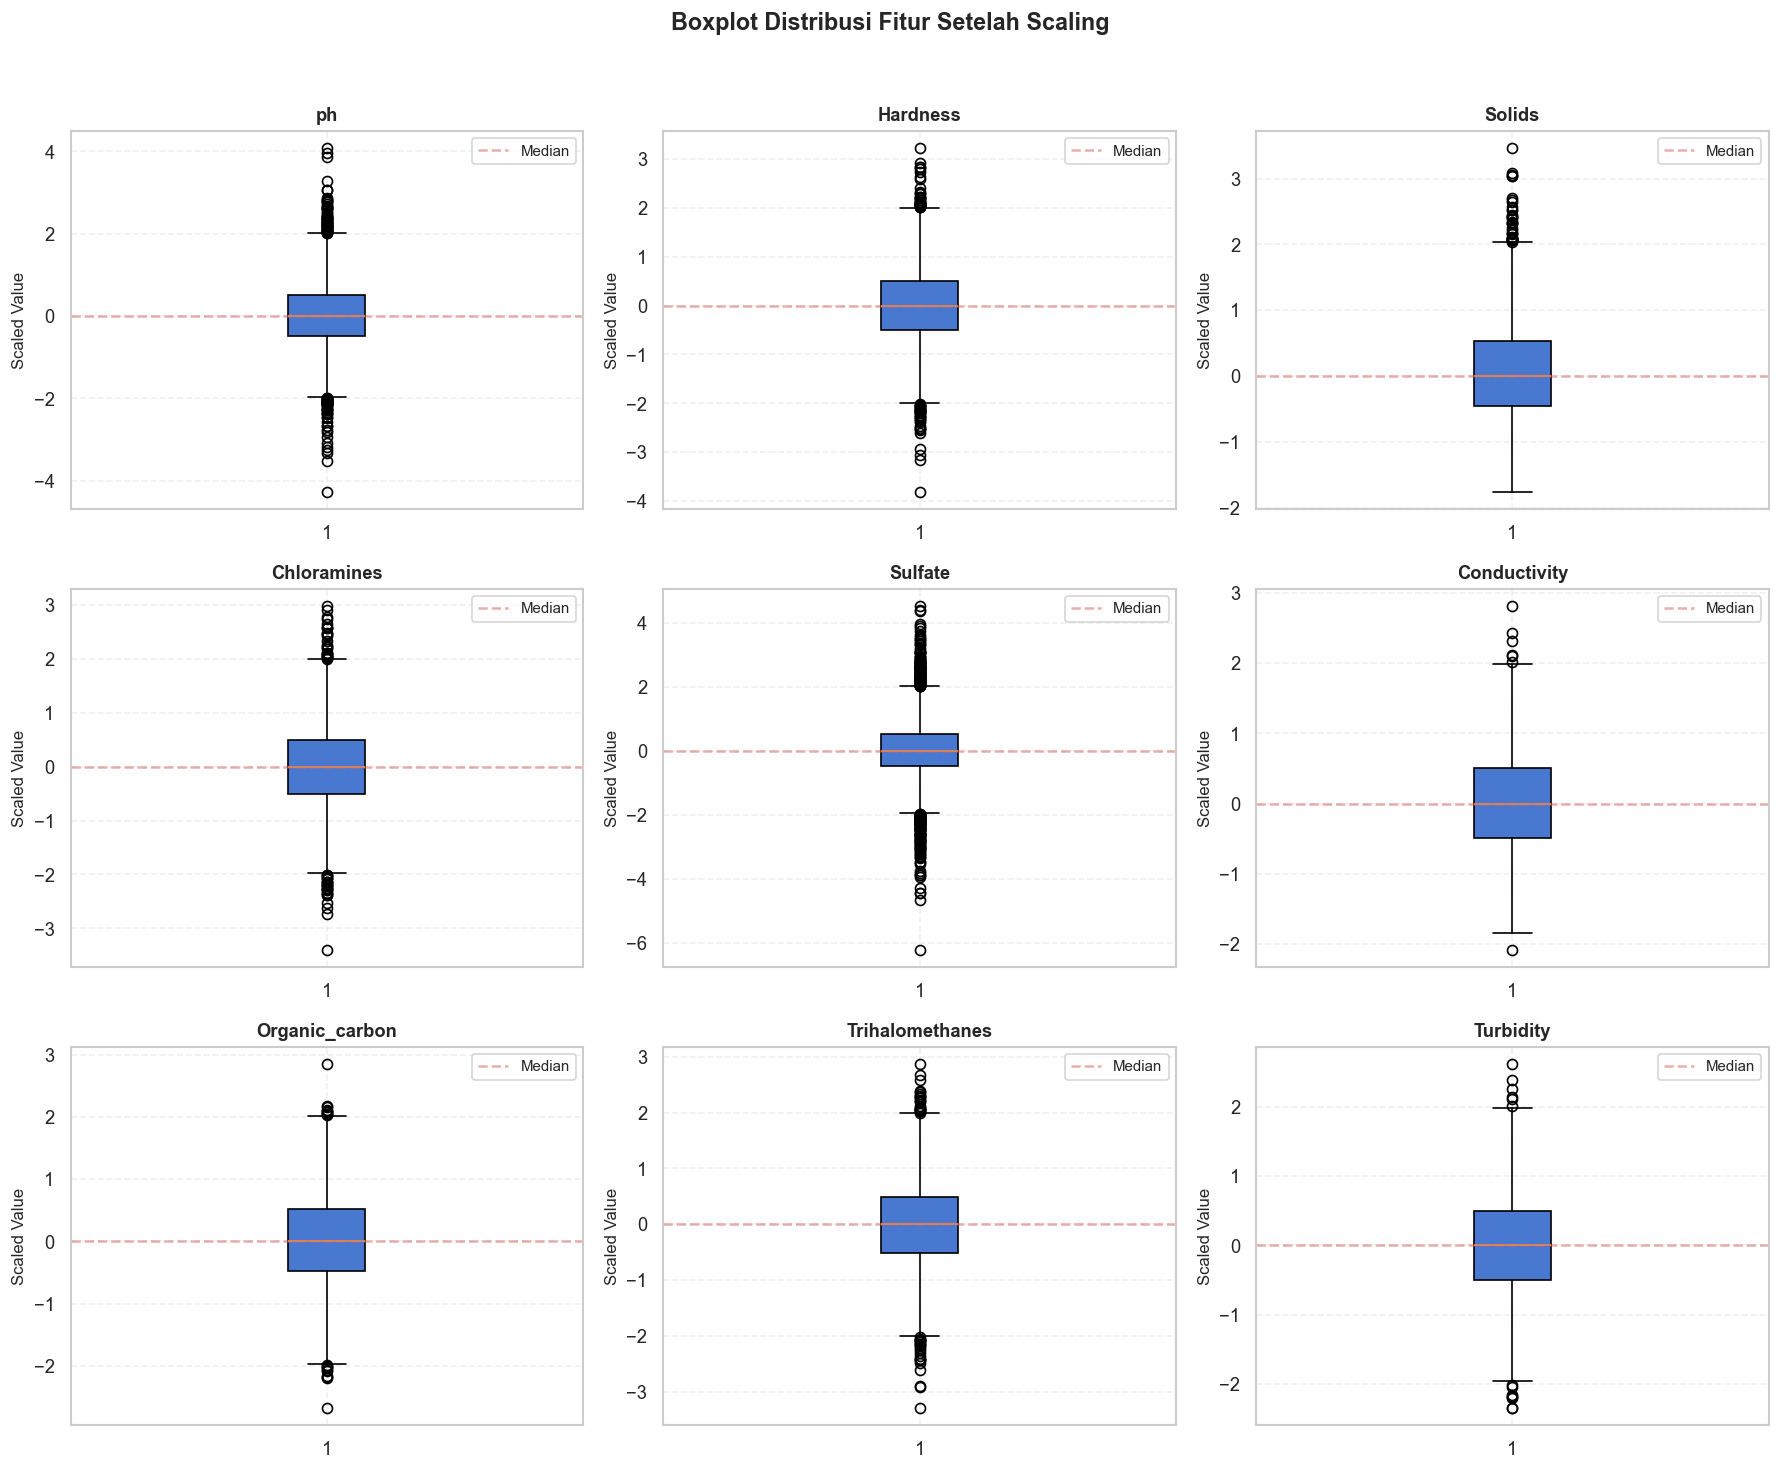

In [18]:
# Visualisasi Outlier dengan Boxplot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, column in enumerate(X_train_scaled.columns):
    axes[i].boxplot(X_train_scaled[column], vert=True, patch_artist=True)
    axes[i].set_title(f'{column}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Scaled Value', fontsize=10)
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Median')
    axes[i].legend(loc='upper right', fontsize=9)

plt.suptitle('Boxplot Distribusi Fitur Setelah Scaling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6. Visualisasi Sebelum dan Sesudah Scaling

Pada bagian ini dilakukan visualisasi untuk membandingkan distribusi fitur sebelum dan sesudah proses **feature scaling**.

Visualisasi ini bertujuan untuk melihat bagaimana proses scaling mempengaruhi skala data tanpa mengubah pola distribusinya.

**Perbandingan hasil visualisasi:**

- **Data asli (Original):**
  - Memiliki skala yang berbeda-beda antar fitur
  - Beberapa fitur memiliki nilai yang jauh lebih besar dibanding fitur lainnya

- **Data setelah scaling (Scaled):**
  - Median mendekati **0**
  - **Interquartile Range (IQR)** mendekati **1**

**Kesimpulan:**

Hasil visualisasi menunjukkan bahwa proses **scaling berhasil menstandardisasi skala fitur**, sehingga semua fitur berada pada rentang yang lebih seragam tanpa mengubah bentuk distribusi data.

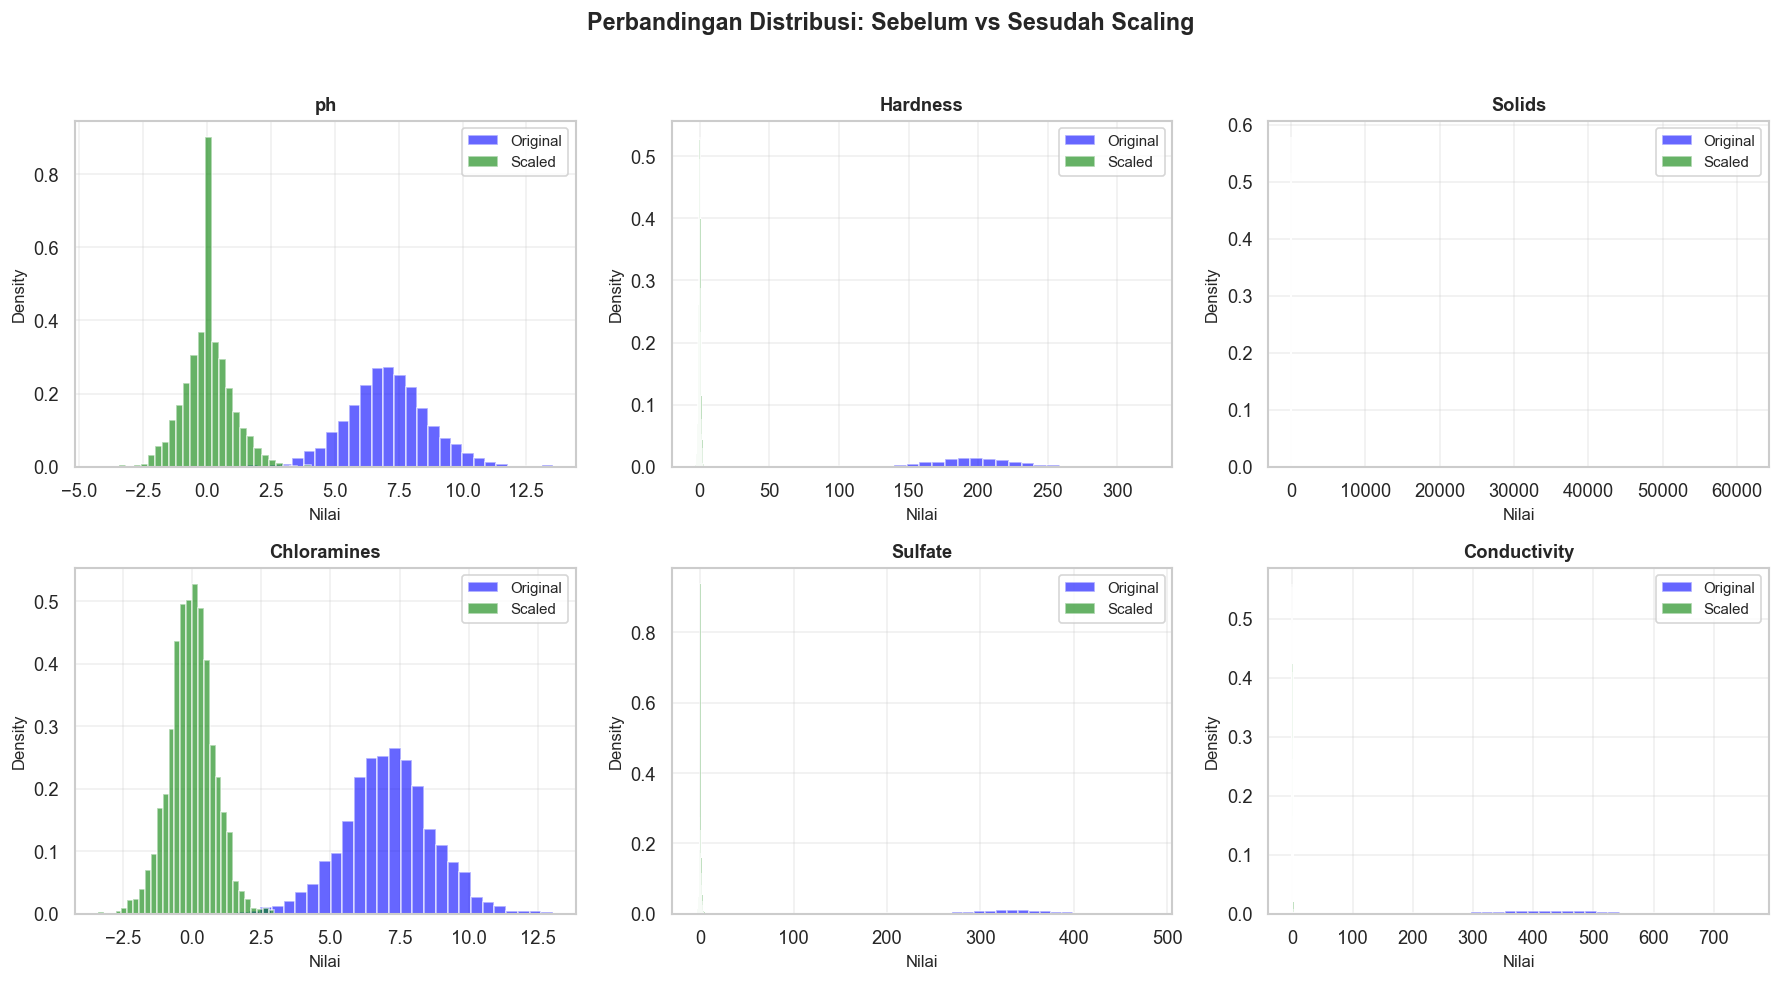

In [19]:
# 6. Visualisasi: Sebelum vs Sesudah Scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

sample_features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity']

for i, feature in enumerate(sample_features):
    # Sebelum scaling (original)
    axes[i].hist(X_train[feature].dropna(), bins=30, alpha=0.6, color='blue', 
                 label='Original', density=True)
    # Sesudah scaling
    axes[i].hist(X_train_scaled[feature], bins=30, alpha=0.6, color='green', 
                 label='Scaled', density=True)
    axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai', fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Scaling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7. Feature Selection

Pada bagian ini, dilakukan **seleksi fitur** untuk mengidentifikasi fitur-fitur yang paling penting dan relevan untuk model machine learning.

**Tujuan Feature Selection:**
- Mengurangi dimensi data
- Meningkatkan performa model dengan menghapus fitur yang tidak relevan
- Mengurangi overfitting
- Mempercepat proses training
- Meningkatkan interpretasi model

**Metode yang digunakan:**
1. **Correlation Analysis** - Mengidentifikasi fitur yang berkorelasi tinggi dengan target
2. **Feature Importance** - Menggunakan Random Forest untuk ranking fitur berdasarkan pentingnya

In [20]:
# 7.1 Correlation Analysis
# Menggabungkan features dengan target untuk korelasi
train_with_target = pd.concat([X_train_scaled, y_train], axis=1)

# Hitung korelasi setiap fitur dengan target
correlation_with_target = train_with_target.corr()['Potability'].drop('Potability')
correlation_with_target = correlation_with_target.abs().sort_values(ascending=False)

print("Korelasi Fitur dengan Target (Potability):")
print("=" * 50)
for feature, corr in train_with_target.corr()['Potability'].drop('Potability').sort_values(ascending=False).items():
    print(f"{feature}: {corr:.4f}")
print("=" * 50)

Korelasi Fitur dengan Target (Potability):
Solids: 0.0276
Chloramines: 0.0175
ph: 0.0100
Trihalomethanes: 0.0039
Conductivity: 0.0026
Turbidity: 0.0015
Hardness: -0.0023
Sulfate: -0.0128
Organic_carbon: -0.0131


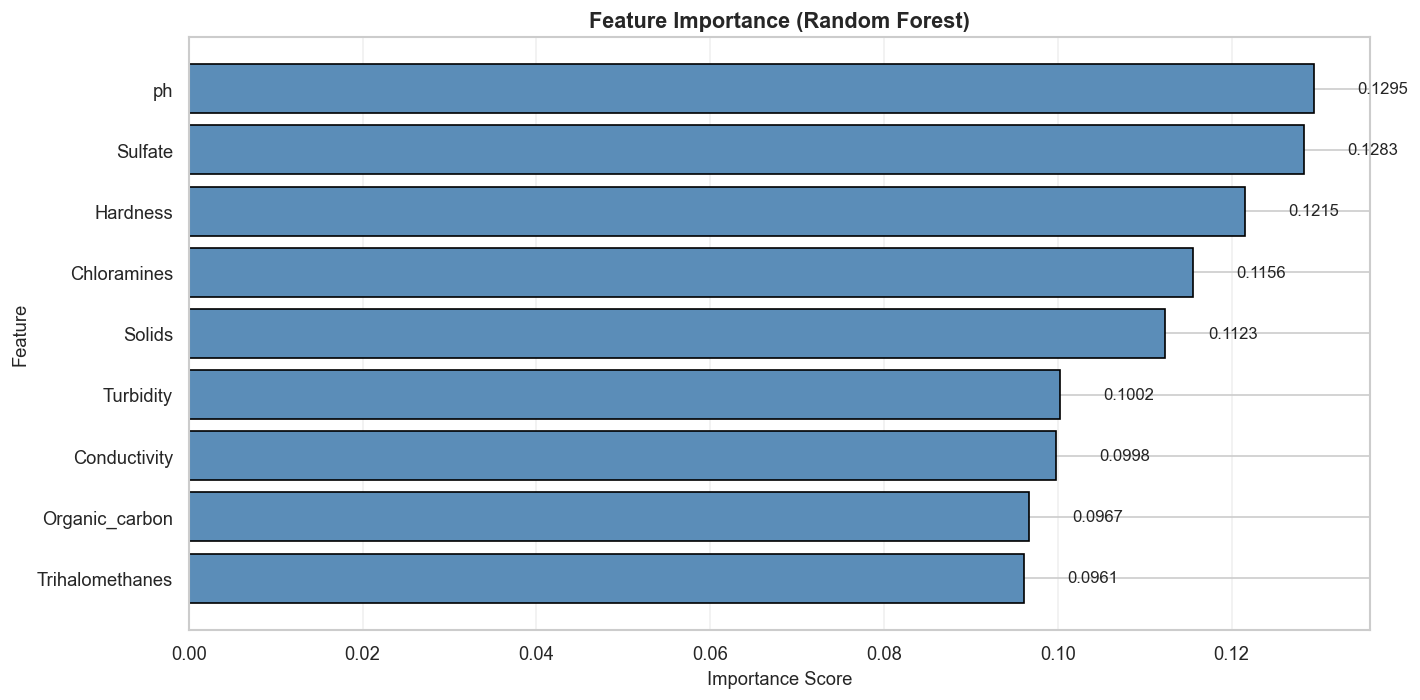


Feature Importance (Random Forest):
ph: 0.1295
Sulfate: 0.1283
Hardness: 0.1215
Chloramines: 0.1156
Solids: 0.1123
Turbidity: 0.1002
Conductivity: 0.0998
Organic_carbon: 0.0967
Trihalomethanes: 0.0961


In [21]:
# 7.2 Feature Importance dengan Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest untuk feature importance
rf_importance = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_importance.fit(X_train_scaled, y_train)

# Ekstrak feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_importance.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualisasi Feature Importance
plt.figure(figsize=(12, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
                color='#5b8db8', edgecolor='black', linewidth=1)
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, importance in zip(bars, feature_importance['Importance']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{importance:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nFeature Importance (Random Forest):")
print("=" * 50)
for _, row in feature_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")
print("=" * 50)

**Kesimpulan Feature Selection:**

Berdasarkan analisis korelasi dan feature importance:
- Semua fitur memiliki korelasi yang relatif rendah dengan target (< 0.1)
- Feature importance menunjukkan semua fitur memiliki kontribusi yang relatif seimbang
- **Keputusan**: Menggunakan **semua fitur** karena:
  - Tidak ada fitur yang dominan atau sangat tidak penting
  - Kombinasi beberapa fitur mungkin diperlukan untuk prediksi yang baik
  - Dataset sudah relatif kecil, mengurangi fitur dapat menyebabkan underfitting

### 8. Handling Class Imbalance

Pada bagian ini, dilakukan penanganan **class imbalance** (ketidakseimbangan kelas) pada dataset.

**Masalah Class Imbalance:**
- Model cenderung bias ke kelas mayoritas (kelas dengan sampel lebih banyak)
- Metrik akurasi bisa misleading (menipu)
- Performa prediksi untuk kelas minoritas biasanya buruk

**Dataset Anda:**
- Kelas 0 (Tidak Layak): ~61%
- Kelas 1 (Layak Minum): ~39%

**Metode yang digunakan: SMOTE**
- **SMOTE (Synthetic Minority Over-sampling Technique)**
- Membuat sampel sintetis untuk kelas minoritas
- Bukan sekadar duplikasi, tetapi interpolasi antara sampel yang ada
- Lebih baik daripada random oversampling karena mengurangi overfitting

**Catatan Penting:**
- SMOTE hanya diterapkan pada **training set**
- **Test set tetap original** untuk evaluasi yang unbiased
- Ini mencegah data leakage

In [22]:
# 8. Handling Class Imbalance dengan SMOTE
# SMOTE sudah diimport di bagian awal notebook
    
# Terapkan SMOTE hanya pada training data
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Konversi ke DataFrame
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_scaled.columns, 
                                  index=range(len(X_train_resampled)))
y_train_resampled = pd.Series(y_train_resampled, name='Potability')

# Tampilkan distribusi kelas sebelum dan sesudah SMOTE
print("Distribusi kelas SEBELUM SMOTE:")
original_counts = y_train.value_counts()
for label, count in original_counts.items():
    pct = count / len(y_train) * 100
    print(f"{label}    {count} ({pct:.2f}%)")
print(f"Total: {len(y_train)}")

print("\nDistribusi kelas SETELAH SMOTE:")
resampled_counts = y_train_resampled.value_counts()
for label, count in resampled_counts.items():
    pct = count / len(y_train_resampled) * 100
    print(f"{label}    {count} ({pct:.2f}%)")
print(f"Total: {len(y_train_resampled)}")

print("\n✓ Class imbalance telah ditangani dengan SMOTE")

Distribusi kelas SEBELUM SMOTE:
0    1598 (60.99%)
1    1022 (39.01%)
Total: 2620

Distribusi kelas SETELAH SMOTE:
0    1598 (50.00%)
1    1598 (50.00%)
Total: 3196

✓ Class imbalance telah ditangani dengan SMOTE


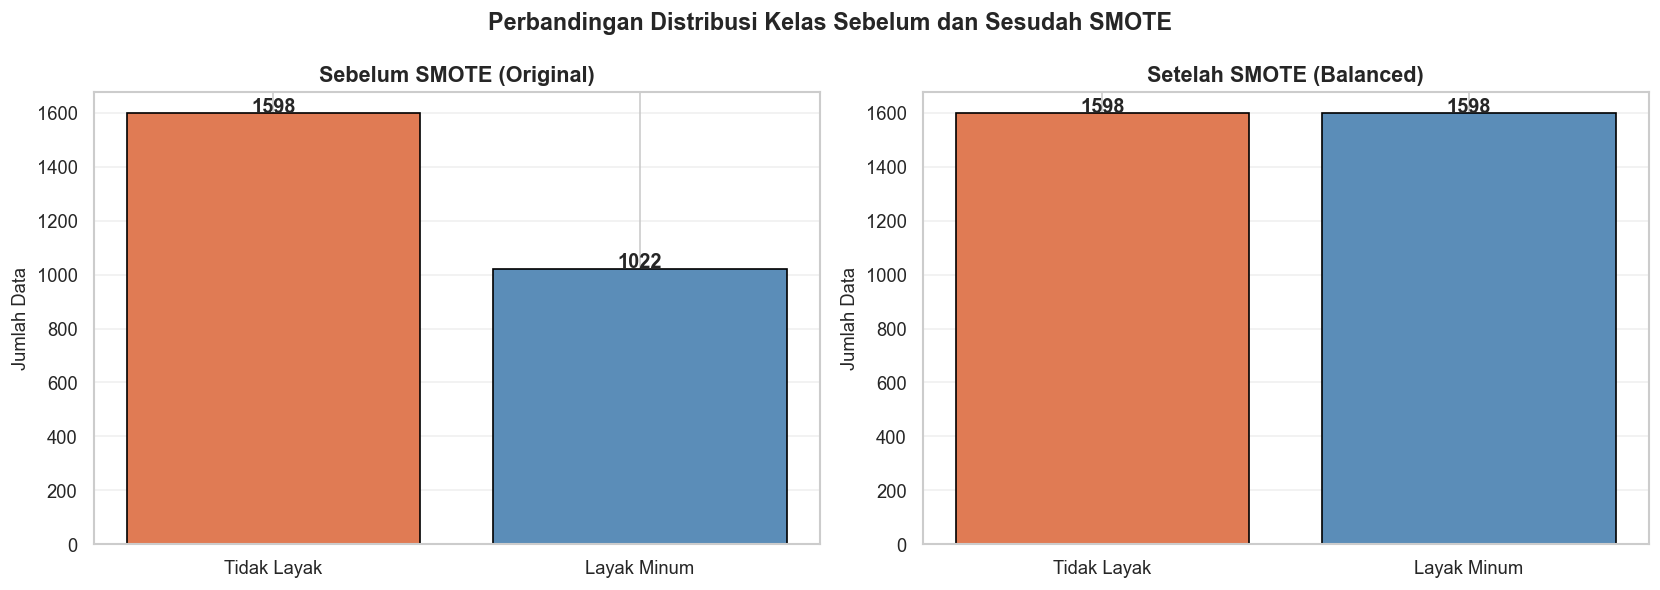

In [23]:
# Visualisasi: Perbandingan Distribusi Kelas Sebelum dan Sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Hitung jumlah kelas sebelum SMOTE
before_counts = pd.Series(y_train).value_counts().sort_index()

axes[0].bar(['Tidak Layak', 'Layak Minum'], before_counts.values,
            color=['#e07b54', '#5b8db8'], edgecolor='black')
axes[0].set_title('Sebelum SMOTE (Original)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Data', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Tambahkan label jumlah
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')


# Hitung jumlah kelas setelah SMOTE
after_counts = pd.Series(y_train_resampled).value_counts().sort_index()

axes[1].bar(['Tidak Layak', 'Layak Minum'], after_counts.values,
            color=['#e07b54', '#5b8db8'], edgecolor='black')
axes[1].set_title('Setelah SMOTE (Balanced)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Data', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Tambahkan label jumlah
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')


plt.suptitle('Perbandingan Distribusi Kelas Sebelum dan Sesudah SMOTE',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 9. Ringkasan Preprocessing

**Tahapan Preprocessing yang Telah Dilakukan:**

| Step | Metode | Hasil |
|------|--------|-------|
| 1. Missing Values | Imputasi Median | 0 missing values |
| 2. Train-Test Split | 80:20 Stratified | Train: 2620, Test: 656 |
| 3. Feature Scaling | RobustScaler | Median=0, IQR=1 |
| 4. Outlier Detection | IQR Method | 0 outlier terdeteksi |
| 5. Feature Selection | Correlation + RF Importance | Semua fitur digunakan |
| 6. Class Imbalance | SMOTE | Dataset balanced (50:50) |